In [2]:
import gc
import numpy as np
import os
import re
import sys
import pandas as pd
import tensorflow_data_validation as tfdv

#VERSION = "20221025"
DATA_DIR = r"Z:\13.Data Science\Projects\2022_GI_Xsell\Data"
PROJECT_DIR = "../"
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
META_DATA_DIR = os.path.join(DATA_DIR, "meta_and_reference_data")
VER_1025_DIR = os.path.join(RAW_DATA_DIR, "20221025")
VER_1118_DIR = os.path.join(RAW_DATA_DIR, "20221118")
VER_1122_DIR = os.path.join(RAW_DATA_DIR, "20221122")
VER_1212_DIR = os.path.join(RAW_DATA_DIR, "20221212")
GI_DATA_DIR = os.path.join(RAW_DATA_DIR, "GI")
PA_DATA_DIR = os.path.join(GI_DATA_DIR, "Travel", "202210")
sys.path.insert(0, DATA_DIR)
sys.path.insert(0, PROJECT_DIR)

from datetime import datetime
from dateutil.relativedelta import relativedelta


# from src.utils.common import PLAN_TYPE_LST, WGP_LST, INFORCE_STATUS_LST
# from src.utils.helper_function import find_plan_type, one_hot

In [3]:
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
BASESTAT_FILE = os.path.join(PA_DATA_DIR, "basestat.parquet")
CLAMBASE_FILE = os.path.join(PA_DATA_DIR, "clambase_df.parquet")
PREMBASE_FILE = os.path.join(PA_DATA_DIR, "prembase.parquet")
CLIENT_DATA_MAPPING_FILE = os.path.join(PROCESSED_DATA_DIR, "processed_client_data.parquet")

# import basestat 


In [5]:
basestat_df = pd.read_parquet(BASESTAT_FILE)


In [6]:
# get useful columns from basestat_df 
useful_basestat=basestat_df[['contrnb','nb_clm','CCDATE','OCCDATE',"COWNNUM",'product','plan1','duration','duration_grp','channel','GWP_initial','period']]


## import prembase file


In [7]:
prembase_df = pd.read_parquet(PREMBASE_FILE)


In [8]:
# convert column CCDATE, TRANDATE to datetime at prembase_df
prembase_df["OCCDATE"] = pd.to_datetime(prembase_df["OCCDATE"], format="%Y%m%d")
prembase_df["CCDATE"] = pd.to_datetime(prembase_df["OCCDATE"], format="%Y%m%d")
prembase_df["TRANDATE"] = pd.to_datetime(prembase_df["TRANDATE"], format="%Y%m%d")
# strip contrnb 
prembase_df['contrnb'] = prembase_df['contrnb'].str.strip()
# strip COWNNUM
prembase_df['COWNNUM'] = prembase_df['COWNNUM'].str.strip()

In [369]:
prembase_df.head()

,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE,CLTSEX,CLTDOB,MARRYD,NATLTY,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp
0,00300028,2011-12-13,50.0,1.0,2.0,20151213.0,423.9,127.17,0.0,2015.0,12.0,1.0,2015-12-05,T413,STX,2011-12-13,20161212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,417.75345,127.17,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATH,99999999.0,PA,NaN,1000000.0,C,C2,2,1.0,N,Annual,20161212.0,NaN,0.0,99999999.0,366.0,1.0,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,8.0,3. 6 to 10 days,1. 1 person,4. Age 41 - 50,4.0,4,NaN,NaN,NaN,0. No Discount
1,00300028,2011-12-13,50.0,2.0,2.0,20151213.0,2402.1,720.63,0.0,2015.0,12.0,1.0,2015-12-05,T413,STX,2011-12-13,20161212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,2367.26955,720.63,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATM,99999999.0,Miscellaneous,NaN,1000000.0,C,C2,2,NaN,N,Annual,20161212.0,NaN,0.0,99999999.0,0.0,NaN,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,8.0,3. 6 to 10 days,1. 1 person,4. Age 41 - 50,4.0,4,NaN,NaN,NaN,0. No Discount
2,00300028,2011-12-13,51.0,1.0,4.0,20161213.0,423.9,127.17,0.0,2016.0,12.0,1.0,2016-12-03,T413,STX,2011-12-13,20171212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,418.60125,127.17,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATH,99999999.0,PA,NaN,1000000.0,C,C2,2,1.0,N,Annual,20171212.0,NaN,0.0,99999999.0,365.0,1.0,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,10.0,3. 6 to 10 days,1. 1 person,5. Age 51 - 60,5.0,5+,NaN,NaN,NaN,0. No Discount
3,00300028,2011-12-13,51.0,2.0,4.0,20161213.0,2402.1,720.63,0.0,2016.0,12.0,1.0,2016-12-03,T413,STX,2011-12-13,20171212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,2372.07375,720.63,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATM,99999999.0,Miscellaneous,NaN,1000000.0,C,C2,2,NaN,N,Annual,20171212.0,NaN,0.0,99999999.0,0.0,NaN,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,10.0,3. 6 to 10 days,1. 1 person,5. Age 51 - 60,5.0,5+,NaN,NaN,NaN,0. No Discount
4,00300028,2011-12-13,52.0,1.0,6.0,20171213.0,423.9,127.17,0.0,2017.0,12.0,1.0,2017-12-07,T413,STX,2011-12-13,20181212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,419.53383,127.17,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATH,99999999.0,PA,NaN,1000000.0,C,C2,2,1.0,N,Annual,20181212.0,NaN,0.0,99999999.0,365.0,1.0,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,6.0,3. 6 to 10 days,1. 1 person,5. Age 51 - 60,6.0,5+,NaN,NaN,NaN,0. No Discount


In [9]:
# get useful columns from prembase_df 
useful_prembase_df=prembase_df[['COWNNUM','contrnb','OCCDATE','channel','product']]
# show shape of useful_prembase_df
useful_prembase_df.shape


(4844657, 5)

In [ ]:
# strip CLINTNUM SECUITYNO modified_SECUITYNO
useful_prembase_df['COWNNUM'] = useful_prembase_df['COWNNUM'].str.strip()
useful_prembase_df['contrnb'] = useful_prembase_df['contrnb'].str.strip()

# conver to datetime
useful_prembase_df["OCCDATE"] = pd.to_datetime(useful_prembase_df["OCCDATE"], format="%Y%m%d")



# import client data

In [10]:
client_data_df = pd.read_parquet(CLIENT_DATA_MAPPING_FILE)

In [405]:
client_data_df.sample(10)

,CLNTNUM,VALIDFLAG,CLTTYPE,SECUITYNO,CLTSEX,OCCPCODE,CLTDOB,START_DATE,MARRYD,NATLTY,modified_SECUITYNO
5939122,3036095,1,P,E683618(A),M,None,19560716.0,20200908.0,M,None,E683618
2733711,N2909291,1,P,K236754(8),M,UNKN,19740103.0,99999999.0,S,None,K236754
5751348,2932500,1,P,Y681469(5),M,None,19990528.0,20190929.0,None,None,Y681469
3589845,M2256289,1,P,Z285177(7),M,UNKN,19831109.0,99999999.0,S,None,Z285177
5413147,1353532,1,C,unknown,None,None,99999999.0,20181127.0,None,None,unknown
1643959,O1286981,1,P,CS0005605317,U,UNKN,99999999.0,99999999.0,None,None,CS0005605317
4882596,2529925,1,P,K345223(9),M,None,19741107.0,20170812.0,None,None,K345223
2341951,O8465851,1,P,A995050(0),F,UNKN,19511216.0,99999999.0,M,None,A995050
1382810,G8984913,1,P,P067845(0),M,OTH,19660821.0,99999999.0,M,None,P067845
4881285,2529070,1,P,P124756(9),F,None,19800927.0,20170810.0,None,None,P124756


In [11]:
# strip CLINTNUM SECUITYNO modified_SECUITYNO
client_data_df['CLNTNUM'] = client_data_df['CLNTNUM'].str.strip()
client_data_df['SECUITYNO'] = client_data_df['SECUITYNO'].str.strip()
client_data_df['modified_SECUITYNO'] = client_data_df['modified_SECUITYNO'].str.strip()



In [12]:
useful_client_data_df=client_data_df[['CLNTNUM','modified_SECUITYNO']]

In [13]:
# value count COWNNUM in useful_prembase_df
print(useful_prembase_df['COWNNUM'].value_counts(dropna=False).sort_values(ascending=False))
# check if any COWNNUM in useful_prembase_df is null
print(useful_prembase_df['COWNNUM'].isnull().sum())

0210264     2009
0094097     1931
O7744783    1329
M2661774    1064
0470277      872
            ... 
1223708        1
1223992        1
1223994        1
1223997        1
1442707        1
Name: COWNNUM, Length: 1499865, dtype: int64
0


In [14]:
#value count CLNTNUM in useful_client_data_df
print(useful_client_data_df['CLNTNUM'].value_counts(dropna=False).sort_values(ascending=False))

print(useful_client_data_df['CLNTNUM'].isnull().sum())

0000001    1
0000016    1
0000007    1
0000008    1
0000010    1
          ..
1709379    1
1709380    1
6080423    1
6080422    1
6080441    1
Name: CLNTNUM, Length: 6139950, dtype: int64
0


In [15]:
print("prembase_df size before merge:", useful_prembase_df.shape)
#COWNNUM=client number 
# left join prembase_df with client_data_df, using column CLNTNUM from client_data_df and column COWNNUM from prembase_df as key
useful_prembase_w_client_df = useful_prembase_df.merge(useful_client_data_df, left_on="COWNNUM", right_on='CLNTNUM' ,how="left")

print("prembase_df size after merge:", useful_prembase_w_client_df.shape)

prembase_df size before merge: (4844657, 5)
prembase_df size after merge: (4844657, 7)


In [379]:
useful_prembase_w_client_df

,COWNNUM,contrnb,OCCDATE,channel,product,CLNTNUM,modified_SECUITYNO
0,N5017122,00300028,2011-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231
1,N5017122,00300028,2011-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231
2,N5017122,00300028,2011-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231
3,N5017122,00300028,2011-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231
4,N5017122,00300028,2011-12-13,Banca - HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231
...,...,...,...,...,...,...,...
4844652,0784814,Z1942661,2022-10-26,Agents & Broker,SmartTraveller Plus (Single),0784814,1434619
4844653,1646667,Z4459258,2021-05-26,Agents & Broker,SmartTraveller Plus (Single),1646667,A123456
4844654,1646667,Z4459258,2021-05-26,Agents & Broker,SmartTraveller Plus (Single),1646667,A123456
4844655,0920580,ZS753243,2016-03-19,AXA Online Direct,SmartTraveller (Single),0920580,Z660017


In [380]:
# see how many rows where COWNNUM is different from CLNTNUM
print(useful_prembase_w_client_df[useful_prembase_w_client_df["COWNNUM"] != useful_prembase_w_client_df["CLNTNUM"]].shape)
useful_prembase_w_client_df[useful_prembase_w_client_df["COWNNUM"] != useful_prembase_w_client_df["CLNTNUM"]].sample(10)


(50933, 7)


,COWNNUM,contrnb,OCCDATE,channel,product,CLNTNUM,modified_SECUITYNO
4838105,1728620,Z1646188,2022-09-09,JLT (OSC),UNICOVER OVERSEAS STUDENT INS,NaN,NaN
4836026,1737678,Z1643775,2022-10-14,LP,SmartTraveller Plus (Single),NaN,NaN
4836222,1737867,Z1643958,2022-10-20,AXA Online Direct,SmartTraveller Plus (Single),NaN,NaN
3204878,6092635,26003185,2022-10-12,Banca - HSBC,Multi Trip 2018,NaN,NaN
4795003,1722759,Z1383671,2022-08-15,Agents & Broker,SmartTraveller Plus (Single),NaN,NaN
4824317,1722334,Z1480429,2022-08-13,LP,UNICOVER OVERSEAS STUDENT INS,NaN,NaN
4824575,1723627,Z1480514,2022-09-01,Agents & Broker,UNICOVER OVERSEAS STUDENT INS,NaN,NaN
4839163,1741206,Z1653111,2022-10-20,Agents & Broker,SmartTraveller Plus (Single),NaN,NaN
3199560,6088587,26000654,2022-08-31,Banca - HSBC,Single Trip 2018,NaN,NaN
3214052,6096889,26007722,2022-10-20,Banca - HSBC,Single Trip 2018,NaN,NaN


In [149]:
# see how many rows where modified_SECUITYNO is NaN, anc value count channel

print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()].shape)

(50933, 7)


In [16]:
# see how many rows where CLNTNUM is NaN, 
print(useful_prembase_w_client_df[useful_prembase_w_client_df["CLNTNUM"].isna()].shape)

(50933, 7)


In [17]:
# number of unique COWNNUM in useful_prembase_w_client_df
print(useful_prembase_w_client_df['COWNNUM'].nunique())

1499865


In [20]:
PERCENTAGE_OF_ROWS_WITHOUT_ID=(50933/1499865)*100
PERCENTAGE_OF_ROWS_WITHOUT_ID

3.395838958839629

In [151]:
# see how many unique COWNNUM where modified_SECUITYNO is NaN
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["COWNNUM"].nunique())

32227


In [22]:
PERCENTAGE_OF_UNIQUE_CLIENTS_WITHOUT_ID=(32227/1499865)*100
PERCENTAGE_OF_UNIQUE_CLIENTS_WITHOUT_ID

2.148660046070813

In [152]:
# see how many channels where modified_SECUITYNO is NaN
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["channel"].value_counts())

Banca - HSBC          23490
AXA Online Direct     12605
Agents & Broker        7358
LP                     6866
Citi                    291
JLT (OSC)               282
AXA Offline Direct       41
Name: channel, dtype: int64


In [153]:
# count min and mix of the OCCDATE of "useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]"
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["OCCDATE"].min())
# useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["OCCDATE"].max())

1998-07-01 00:00:00
2023-01-23 00:00:00


In [154]:
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["product"].value_counts())

SmartTraveller Plus (Single)                 18060
Single Trip 2018                             15652
UNICOVER OVERSEAS STUDENT INS                 5701
Multi Trip 2018                               4804
SmartTraveller Plus (Annual)                  3336
Overseas StudySurance                         3012
SmartTraveller- Citi                           291
SmartTraveller (Single)                         27
MultiTrip TravelSurance (Monthly payment)       16
SmartTraveller (Annual)                         11
Group Biz Travel                                 9
Supreme Travel                                   8
MultiTrip TravelSurance (Annual)                 4
BUSINESS TRAVELCARE                              2
Name: product, dtype: int64


In [23]:
# drop rows where modified_SECUITYNO is NaN as the percentage only 2.14
useful_prembase_w_client_df = useful_prembase_w_client_df.dropna(subset=["modified_SECUITYNO"])

In [24]:
# see how many rows where COWNNUM is different from CLNTNUM
print(useful_prembase_w_client_df[useful_prembase_w_client_df["COWNNUM"] != useful_prembase_w_client_df["CLNTNUM"]].shape)

(0, 7)


In [25]:
DUMMY_ID=['unknown','A123456','F123456']
#drop if modified_SECUITYNO is in DUMMY_ID
useful_prembase_w_client_df = useful_prembase_w_client_df[~useful_prembase_w_client_df["modified_SECUITYNO"].isin(DUMMY_ID)]




In [26]:
# drop the column COWNNUM
useful_prembase_w_client_df = useful_prembase_w_client_df.drop(columns=["COWNNUM"])

# Update channel names

In [1]:
modi_channels={
    'Banca - HSBC':'HSBC',
    'Agents & Broker':'Broker',
    'AXA Online Direct':'AXA Direct',
    'AXA Offline Direct':'AXA Direct',
    'LP':'Life Agent',
    'Citi':'others',
    'JLT (OSC)': 'others'
}

In [2]:
# strip the space in the column 'channel' in useful_prembase_w_client_df
useful_prembase_w_client_df['channel'] = useful_prembase_w_client_df['channel'].str.strip()
#replace the value in the column "channel" with the value in the dictionary "modi_channels"
useful_prembase_w_client_df['channel']=useful_prembase_w_client_df['channel'].map(modi_channels)

NameError: name 'useful_prembase_w_client_df' is not defined

In [31]:
ch=['HSBC','Broker','AXA Direct','Live Agent','others']

In [32]:
#generate a new DF named "By_Channel" , which has columns name 'HSBC','Broker','AXA Direct','Live Agent','others'
By_Channel = pd.DataFrame(columns=['HSBC','Broker','AXA Direct','Live Agent','others'])

# read clambase

In [3]:
clambase_df = pd.read_parquet(CLAMBASE_FILE)


NameError: name 'pd' is not defined

In [28]:
clambase_df.head()

,CLAIM,CNTTYPE,RSKNO,DATOCC,DATREP,CLSTAT,MEVENT,SERVBR,contrnb,ldf,clmldf,zdmind_clm,clmdsc,RSCD,rscd_des,chgbal_n,paymnt_n,chgbal_g,paymnt_g,incur_g,incur_n,ultincur_n,ay,am,nb_clm,ult_clm,nb_rscd,large,lrg_nb_clm,AF_nb_clm,AF_ultclm,AF_incur_g,AF_incur_n,AF_ultincur,AL_nb_clm,AL_ultclm,AL_incur_g,AL_incur_n,AL_ultincur,AQ_nb_clm,AQ_ultclm,AQ_incur_g,AQ_incur_n,AQ_ultincur,AW_nb_clm,AW_ultclm,AW_incur_g,AW_incur_n,AW_ultincur,BD_nb_clm,BD_ultclm,BD_incur_g,BD_incur_n,BD_ultincur,BP_nb_clm,BP_ultclm,BP_incur_g,BP_incur_n,BP_ultincur,BU_nb_clm,BU_ultclm,BU_incur_g,BU_incur_n,BU_ultincur,CA_nb_clm,CA_ultclm,CA_incur_g,CA_incur_n,CA_ultincur,CB_nb_clm,CB_ultclm,CB_incur_g,CB_incur_n,CB_ultincur,CD_nb_clm,CD_ultclm,CD_incur_g,CD_incur_n,CD_ultincur,CE_nb_clm,CE_ultclm,CE_incur_g,CE_incur_n,CE_ultincur,CI_nb_clm,CI_ultclm,CI_incur_g,CI_incur_n,CI_ultincur,CK_nb_clm,CK_ultclm,CK_incur_g,CK_incur_n,CK_ultincur,CM_nb_clm,CM_ultclm,CM_incur_g,CM_incur_n,CM_ultincur,CO_nb_clm,CO_ultclm,CO_incur_g,CO_incur_n,CO_ultincur,CS_nb_clm,CS_ultclm,CS_incur_g,CS_incur_n,CS_ultincur,CU_nb_clm,CU_ultclm,CU_incur_g,CU_incur_n,CU_ultincur,DE_nb_clm,DE_ultclm,DE_incur_g,DE_incur_n,DE_ultincur,DI_nb_clm,DI_ultclm,DI_incur_g,DI_incur_n,DI_ultincur,DN_nb_clm,DN_ultclm,DN_incur_g,DN_incur_n,DN_ultincur,DP_nb_clm,DP_ultclm,DP_incur_g,DP_incur_n,DP_ultincur,DY_nb_clm,DY_ultclm,DY_incur_g,DY_incur_n,DY_ultincur,EA_nb_clm,EA_ultclm,EA_incur_g,EA_incur_n,EA_ultincur,EF_nb_clm,EF_ultclm,EF_incur_g,EF_incur_n,EF_ultincur,EV_nb_clm,EV_ultclm,EV_incur_g,EV_incur_n,EV_ultincur,FE_nb_clm,FE_ultclm,FE_incur_g,FE_incur_n,FE_ultincur,FG_nb_clm,FG_ultclm,FG_incur_g,FG_incur_n,FG_ultincur,GH_nb_clm,GH_ultclm,GH_incur_g,GH_incur_n,GH_ultincur,GQ_nb_clm,GQ_ultclm,GQ_incur_g,GQ_incur_n,GQ_ultincur,HC_nb_clm,HC_ultclm,HC_incur_g,HC_incur_n,HC_ultincur,HE_nb_clm,HE_ultclm,HE_incur_g,HE_incur_n,HE_ultincur,HS_nb_clm,HS_ultclm,HS_incur_g,HS_incur_n,HS_ultincur,IC_nb_clm,IC_ultclm,IC_incur_g,IC_incur_n,IC_ultincur,IF_nb_clm,IF_ultclm,IF_incur_g,IF_incur_n,IF_ultincur,IN_nb_clm,IN_ultclm,IN_incur_g,IN_incur_n,IN_ultincur,IP_nb_clm,IP_ultclm,IP_incur_g,IP_incur_n,IP_ultincur,LK_nb_clm,LK_ultclm,LK_incur_g,LK_incur_n,LK_ultincur,ME_nb_clm,ME_ultclm,ME_incur_g,ME_incur_n,ME_ultincur,MO_nb_clm,MO_ultclm,MO_incur_g,MO_incur_n,MO_ultincur,MS_nb_clm,MS_ultclm,MS_incur_g,MS_incur_n,MS_ultincur,OD_nb_clm,OD_ultclm,OD_incur_g,OD_incur_n,OD_ultincur,OL_nb_clm,OL_ultclm,OL_incur_g,OL_incur_n,OL_ultincur,OP_nb_clm,OP_ultclm,OP_incur_g,OP_incur_n,OP_ultincur,OT_nb_clm,OT_ultclm,OT_incur_g,OT_incur_n,OT_ultincur,PA_nb_clm,PA_ultclm,PA_incur_g,PA_incur_n,PA_ultincur,PB_nb_clm,PB_ultclm,PB_incur_g,PB_incur_n,PB_ultincur,PE_nb_clm,PE_ultclm,PE_incur_g,PE_incur_n,PE_ultincur,PL_nb_clm,PL_ultclm,PL_incur_g,PL_incur_n,PL_ultincur,PO_nb_clm,PO_ultclm,PO_incur_g,PO_incur_n,PO_ultincur,PQ_nb_clm,PQ_ultclm,PQ_incur_g,PQ_incur_n,PQ_ultincur,PW_nb_clm,PW_ultclm,PW_incur_g,PW_incur_n,PW_ultincur,RC_nb_clm,RC_ultclm,RC_incur_g,RC_incur_n,RC_ultincur,RE_nb_clm,RE_ultclm,RE_incur_g,RE_incur_n,RE_ultincur,RH_nb_clm,RH_ultclm,RH_incur_g,RH_incur_n,RH_ultincur,SA_nb_clm,SA_ultclm,SA_incur_g,SA_incur_n,SA_ultincur,SI_nb_clm,SI_ultclm,SI_incur_g,SI_incur_n,SI_ultincur,SK_nb_clm,SK_ultclm,SK_incur_g,SK_incur_n,SK_ultincur,TB_nb_clm,TB_ultclm,TB_incur_g,TB_incur_n,TB_ultincur,TC_nb_clm,TC_ultclm,TC_incur_g,TC_incur_n,TC_ultincur,TD_nb_clm,TD_ultclm,TD_incur_g,TD_incur_n,TD_ultincur,TH_nb_clm,TH_ultclm,TH_incur_g,TH_incur_n,TH_ultincur,TI_nb_clm,TI_ultclm,TI_incur_g,TI_incur_n,TI_ultincur,TP_nb_clm,TP_ultclm,TP_incur_g,TP_incur_n,TP_ultincur,UI_nb_clm,UI_ultclm,UI_incur_g,UI_incur_n,UI_ultincur,WB_nb_clm,WB_ultclm,WB_incur_g,WB_incur_n,WB_ultincur,lrg_incur_g,lrg_incur_n,lrg_ultincur,ClosedRSCD,ClosedClm,PLASIC,COUNTRY,DTEEFF,CCDATE,ZDMIND
0,Y0383836,STX,2.0,20160228.0,20160314.0,2,NA,20,00300316,0.952674,1.0,N,Damage to baggage ella,PB,PERSONAL EFFECTS,0.0,650.0,0.0,650.0,650.0,650.0,619.23810,2016.0,201602.0,1.0,1.

In [33]:
# show only colume 'CLAIM' ,'CLSTAT','CCDATE' in claim base
useful_clambase_df=clambase_df[['CLAIM','CCDATE','contrnb','DATOCC','DATREP']]




In [34]:
# see if there's any contrnb in useful_clambase_df that is not in prembase_df
# print(useful_clambase_df[~useful_clambase_df["contrnb"].isin(prembase_df["contrnb"])].shape)

print(useful_clambase_df[~useful_clambase_df["contrnb"].isin(prembase_df["contrnb"])]['contrnb'].nunique())

###why????????

1332


In [35]:
# see if there's any unique contrnb in useful_clambase_df that is not in useful_prembase_w_client_df
useful_clambase_df[~useful_clambase_df["contrnb"].isin(prembase_df["contrnb"])]['contrnb'].nunique()

1332

In [36]:
print("clambase_df shape:", useful_clambase_df.shape)
# drop all contrnb in useful_clambase_df that is not in useful_prembase_w_client_df
useful_clambase_drop_not_in_usefulprembase = useful_clambase_df[useful_clambase_df["contrnb"].isin(useful_prembase_w_client_df["contrnb"])]


print("clambase_df shape:", useful_clambase_drop_not_in_usefulprembase.shape)

clambase_df shape: (227202, 364)
clambase_df shape: (164648, 5)


In [37]:
useful_clambase_drop_not_in_usefulprembase.shape

(164648, 5)

In [38]:
# see if there's any unique contrnb in useful_clambase_drop_not_in_usefulprembase that is not in useful_prembase_w_client_df
useful_clambase_drop_not_in_usefulprembase[~useful_clambase_drop_not_in_usefulprembase["contrnb"].isin(useful_prembase_w_client_df["contrnb"])]['contrnb'].nunique()


0

In [169]:
print("clambase_df shape:", clambase_df.shape)
print("number of policies:", clambase_df['contrnb'].nunique())

clambase_df shape: (227202, 364)
number of policies: 138324


In [170]:
useful_prembase_w_client_df.shape

(4725417, 6)

In [39]:
# merge useful_clambase_drop_not_in_usefulprembase with useful_prembase_w_client_df on contrnb only
useful_prembase_w_client_w_clambase_df = pd.merge(useful_prembase_w_client_df, useful_clambase_drop_not_in_usefulprembase, on=['contrnb'], how='left')
useful_prembase_w_client_w_clambase_df.shape

(4946438, 10)

# useful_prembase_w_client_w_clambase_df

In [41]:
useful_prembase_w_client_w_clambase_df

,contrnb,OCCDATE,channel,product,CLNTNUM,modified_SECUITYNO,CLAIM,CCDATE,DATOCC,DATREP
0,00300028,2011-12-13,HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231,NaN,NaN,NaN,NaN
1,00300028,2011-12-13,HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231,NaN,NaN,NaN,NaN
2,00300028,2011-12-13,HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231,NaN,NaN,NaN,NaN
3,00300028,2011-12-13,HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231,NaN,NaN,NaN,NaN
4,00300028,2011-12-13,HSBC,MultiTrip TravelSurance (Annual),N5017122,D573231,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4946433,Z1942637,2022-11-04,Broker,SmartTraveller (Single),1046004,D241066,NaN,NaN,NaN,NaN
4946434,Z1942650,2022-10-25,Broker,SmartTraveller Plus (Single),0361142,K957229,NaN,NaN,NaN,NaN
4946435,Z1942661,2022-10-26,Broker,SmartTraveller Plus (Single),0784814,1434619,NaN,NaN,NaN,NaN
4946436,ZS753243,2016-03-19,AXA Direct,SmartTraveller (Single),0920580,Z660017,NaN,NaN,NaN,NaN


In [59]:
pcc_groupby=useful_prembase_w_client_w_clambase_df

# import L&H

In [42]:
#### import L&H app data
health_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "HEALTH_APPLICATION_19970101.parquet"))
health_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "HEALTH_APPLICATION_HISTORIC_19970101.parquet"))
life_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "LIFE_APPLICATION_19970101.parquet"))
life_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "LIFE_APPLICATION_HISTORIC_19970101.parquet"))
dis_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "DISABLE_APPLICATION_19970101.parquet"))
dis_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "DISABLE_APPLICATION_HISTORIC_19970101.parquet"))

In [43]:
all_app_wo_rider_df = pd.concat([health_app_df, health_app_his_df, life_app_df, life_app_his_df, dis_app_df, dis_app_his_df], axis=0)

print("all_app_wo_rider_df size before drop duplicates:", all_app_wo_rider_df.shape)
# check the number of duplicated POLICY_NO at all_app_wo_rider_df
print("number of duplicated PNO:", all_app_wo_rider_df["POLICY_NO"].duplicated().sum())

# drop duplicates of POLICY_NO at all_app_wo_rider_df
all_app_wo_rider_df.drop_duplicates("POLICY_NO", inplace=True)
print("all_app_wo_rider_df size after drop duplicates:", all_app_wo_rider_df.shape)
# convert SUBMIT_DATE to datetime
all_app_wo_rider_df["SUBMIT_DATE"] = pd.to_datetime(all_app_wo_rider_df["SUBMIT_DATE"], format="%Y%m%d")

print("before filter by 2002-01-01:", all_app_wo_rider_df.shape)

# keep all_app_wo_rider_df with "SUBMIT_DATE" >= "20020101"
all_app_wo_rider_df = all_app_wo_rider_df[all_app_wo_rider_df["SUBMIT_DATE"] >= pd.to_datetime(20020101, format="%Y%m%d")]

print("after filter by 2002-01-01:", all_app_wo_rider_df.shape)

all_app_wo_rider_df size before drop duplicates: (2454138, 85)
number of duplicated PNO: 8
all_app_wo_rider_df size after drop duplicates: (2454130, 85)
before filter by 2002-01-01: (2454130, 85)
after filter by 2002-01-01: (1921779, 85)


In [44]:
print(list(all_app_wo_rider_df.columns))

['APPROVAL_DATE_FIRST', 'APPROVAL_DATE_LAST', 'POLICY_NO', 'SUBMIT_DATE', 'ISSUE_DATE', 'LAST_UW_DATE', 'FOLLOWUP_DATE', 'UW_REMARKS_1', 'UW_REMARKS_2', 'UW_REMARKS_3', 'APP_STATUS_CODE', 'UN_CODE', 'SUBSTDECLINE_OPTION', 'POLICY_DATE', 'EXPIRY_DATE', 'MEDICAL_CODE', 'LANGUAGE_FLAG', 'PAYMENT_MODE', 'PAYMENT_METHOD', 'LOCATION_OF_POLICY', 'MONTHS_DEBITED', 'POLICY_FACTOR', 'CURRENCY', 'TOTAL_LOADING', 'ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR', 'MODAL_PREM_EXCLUDE_TOPUP_REGULAR', 'AGENT_1_CODE', 'AGENT_2_CODE', 'INSURED_NAME', 'SEX', 'AGE_AT_ISSUE', 'BIRTH_DATE', 'ID_NO', 'MARITAL_STATUS', 'INCOME_LEVEL', 'CORR_ADDRESS1', 'CORR_ADDRESS2', 'CORR_ADDRESS3', 'CORR_ADDRESS4', 'CORR_CITY_CODE', 'OWNER', 'OWNER_HKID', 'OWNER_GENDER', 'INSURED_PREV_POLICY_NO1', 'INSURED_PREV_POLICY_NO2', 'INSURED_PREV_POLICY_NO3', 'INSURED_PREV_POLICY_NO4', 'INSURED_PREV_POLICY_NO5', 'INSURED_PREV_POLICY_NO6', 'INSURED_PREV_POLICY_NO7', 'INSURED_PREV_POLICY_NO8', 'INSURED_PREV_POLICY_NO9', 'INSURED_PREV_POLICY_NO10'

In [45]:
# change SUBMIT_DATE and POLICY_DATE to datetime format 
all_app_wo_rider_df["SUBMIT_DATE"] = pd.to_datetime(all_app_wo_rider_df["SUBMIT_DATE"], format="%Y%m%d")
all_app_wo_rider_df["POLICY_DATE"] = pd.to_datetime(all_app_wo_rider_df["POLICY_DATE"], format="%Y%m%d")
# strip all the space in OWNER_HKID and ID_NO
all_app_wo_rider_df["OWNER_HKID"] = all_app_wo_rider_df["OWNER_HKID"].str.strip()
all_app_wo_rider_df["ID_NO"] = all_app_wo_rider_df["ID_NO"].str.strip()


In [ ]:
if ID_NO is Nan Use OWNER_HKID

In [46]:
useful_LH=all_app_wo_rider_df[['POLICY_NO','SUBMIT_DATE','POLICY_DATE','ID_NO','OWNER_HKID']]

In [47]:
useful_LH

,POLICY_NO,SUBMIT_DATE,POLICY_DATE,ID_NO,OWNER_HKID
0,505-5925449,2022-10-10,2022-10-08,E393791,
1,505-5925183,2022-10-10,2022-10-25,Z134742,
2,505-5925548,2022-10-10,2022-10-20,K898720,
3,505-5925340,2022-10-10,2022-10-21,S743037,K880895
4,505-5925464,2022-10-10,2022-10-08,E406942,
...,...,...,...,...,...
5453,505-5294515,2022-06-24,2022-06-24,Y343203,
5454,505-5727746,2022-07-18,2022-07-27,C615117,
5455,505-5729882,2022-07-21,2022-08-15,M348055,
5456,505-5747264,2022-08-18,2022-08-25,Z947224,


In [54]:
# if ID_NO == '', change it to NaN
useful_LH.loc[useful_LH["ID_NO"] == '', "ID_NO"] = np.nan

c:\Users\Nicole.Leung\Anaconda3\lib\site-packages\pandas\core\indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


In [56]:
# see if theres' any NaN in OWNER_HKID
useful_LH[useful_LH["ID_NO"].isna()]
# useful_LH[useful_LH["OWNER_HKID"]=]

# useful_LH
# useful_LH


,POLICY_NO,SUBMIT_DATE,POLICY_DATE,ID_NO,OWNER_HKID
18,303-6184913,2012-03-27,2012-03-28,NaN,K662802
2779,588-9134747,2017-04-25,2017-04-19,NaN,V073172
4073,505-5920143,2022-09-29,2022-11-11,NaN,D614201
123907,302-6047153,2002-01-04,2002-01-03,NaN,
123929,302-6047898,2002-01-04,2002-01-01,NaN,
...,...,...,...,...,...
1906886,505-5564222,2022-03-31,2022-03-28,NaN,
1915500,505-5719743,2022-06-30,2022-06-28,NaN,
1919130,505-5747736,2022-08-19,2022-08-25,NaN,M524466
1921157,505-5860380,2022-09-13,2022-09-19,NaN,M138695


In [80]:
#10765 of ID_NO is empty
#10765/1921779

0.0056015806187912345

In [97]:
# 405442 of OWNER_HKID is not empty
405442/1921779

0.21097222937705115

In [57]:
# change SUBMIT_DATE and POLICY_DATE to datetime format 
useful_LH["SUBMIT_DATE"] = pd.to_datetime(useful_LH["SUBMIT_DATE"], format="%Y%m%d")
useful_LH["POLICY_DATE"] = pd.to_datetime(useful_LH["POLICY_DATE"], format="%Y%m%d")


C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_18476/153079825.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_LH["SUBMIT_DATE"] = pd.to_datetime(useful_LH["SUBMIT_DATE"], format="%Y%m%d")
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_18476/153079825.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_LH["POLICY_DATE"] = pd.to_datetime(useful_LH["POLICY_DATE"], format="%Y%m%d")


In [58]:
#print shape of useful_LH
print(useful_LH.shape)
# drop ID_NO if it's NaN
useful_LH = useful_LH[useful_LH["ID_NO"].notna()]
#print shape of useful_LH
print(useful_LH.shape)

(1921779, 5)
(1911014, 5)


In [107]:
1921779-10765

1911014

# pcc_groupby and LH

In [60]:
# see how many ID_NO in useful_LH are the same as modified_SECUITYNO in pcc_groupby
print("number of ID_NO in useful_LH are the same as modified_SECUITYNO in pcc_groupby:", useful_LH[useful_LH["ID_NO"].isin(pcc_groupby["modified_SECUITYNO"])].shape[0])


number of ID_NO in useful_LH are the same as modified_SECUITYNO in pcc_groupby: 344634


In [61]:
# show ID_NO == G141136 and unique POLICY_NO then sort by SUBMIT_DATE
useful_LH[useful_LH["ID_NO"] == "G674182"].sort_values(by="SUBMIT_DATE")

,POLICY_NO,SUBMIT_DATE,POLICY_DATE,ID_NO,OWNER_HKID
414549,502-6143007,2002-03-08,2002-03-08,G674182,
424794,502-6280460,2002-04-25,2002-04-25,G674182,
468393,502-6896513,2003-03-07,2003-03-07,G674182,
468408,502-6896877,2003-03-07,2003-03-06,G674182,
478427,502-7043149,2003-05-09,2003-06-07,G674182,
...,...,...,...,...,...
1876571,305-5139913,2021-11-01,2021-11-08,G674182,
1876570,305-5139871,2021-11-01,2021-11-08,G674182,
1876644,305-5140010,2021-11-01,2021-11-15,G674182,
1876572,305-5139939,2021-11-01,2021-11-08,G674182,


# probability of have or have not DATREP in between OCCDATE and SUBMIT_DATE

In [ ]:
I have 2 dataframe, useful_LH and pcc_groupby
useful_LH is about medical insurance application data
pcc_groupby is about travel insurance data
useful_LH columns: Index(['POLICY_NO', 'SUBMIT_DATE', 'POLICY_DATE', 'ID_NO', 'OWNER_HKID'], dtype='object')
pcc_groupby columns: Index(['contrnb', 'CLAIM', 'OCCDATE', 'channel', 'product', 'CLNTNUM',
       'modified_SECUITYNO', 'CLSTAT', 'CCDATE', 'DATOCC', 'DATREP'],
      dtype='object')
There's some important columns you need to know:
OCCDATE: date of buying travel insurance
DATREP = date of reporting accident in travel insurance
SUBMIT_DATE = date of buying medical insurance 
the data of the column ID_NO in useful_LH == the column modified_SECUITYNO in pcc_groupby, they are the same, means the same person.

The task is to help me to :
1)find the probability of having SUBMIT_DATE within 1 year after OCCDATE and with DATREP in between OCCDATE and SUBMIT_DATE.
2)find the probability of having SUBMIT_DATE within 1 year after OCCDATE and without DATREP in between OCCDATE and SUBMIT_DATE.

In [64]:
import pandas as pd
import numpy as np

# # Load the dataframes
# useful_LH = pd.read_csv('useful_LH.csv')
# pcc_groupby = pd.read_csv('pcc_groupby.csv')

# Convert dates to datetime objects

useful_LH['SUBMIT_DATE'] = pd.to_datetime(useful_LH['SUBMIT_DATE'], format="%Y%m%d")
useful_LH['POLICY_DATE'] = pd.to_datetime(useful_LH['POLICY_DATE'], format="%Y%m%d")
pcc_groupby['OCCDATE'] = pd.to_datetime(pcc_groupby['OCCDATE'], format="%Y%m%d")
pcc_groupby['DATREP'] = pd.to_datetime(pcc_groupby['DATREP'], format="%Y%m%d")

# Merge the dataframes on the ID_NO and modified_SECUITYNO columns
merged = pd.merge(useful_LH, pcc_groupby, left_on='ID_NO', right_on='modified_SECUITYNO')




In [72]:

one_y=pd.DateOffset(years=1)

year = pd.DateOffset(years=1)
# Filter the data to include only rows where SUBMIT_DATE is within 1 year of OCCDATE
filtered = merged[(merged['SUBMIT_DATE'] >= merged['OCCDATE']) & (merged['SUBMIT_DATE'] <= merged['OCCDATE'] + year)]

###################################################################################################
# # Filter the data to include only rows where SUBMIT_DATE is at x year later of OCCDATE
# filtered = merged[(merged['SUBMIT_DATE'] >= merged['OCCDATE'] + (year-one_y)) & (merged['SUBMIT_DATE'] <= merged['OCCDATE'] + year)] 
# ###################################################################################################


In [74]:
# drop OWER_HKID, POLICY_DATE, CLAIM, DATOCC
filtered = filtered.drop(columns=['OWNER_HKID', 'POLICY_DATE', 'CLAIM', 'DATOCC'])


In [77]:
filtered.head(3)

,POLICY_NO,SUBMIT_DATE,ID_NO,contrnb,OCCDATE,channel,product,CLNTNUM,modified_SECUITYNO,CCDATE,DATREP
5609,505-5620255,2022-10-20,D701990,26003756,2022-10-20,HSBC,Single Trip 2018,2890082,D701990,NaN,NaT
948799,505-5652035,2022-10-27,D608416,Z1916984,2022-09-28,Live Agent,UNICOVER OVERSEAS STUDENT INS,1660176,D608416,NaN,NaT
1316136,305-5389369,2022-10-26,R667608,Z1649880,2022-09-14,Live Agent,UNICOVER OVERSEAS STUDENT INS,0937567,R667608,NaN,NaT


In [75]:

# Filter to include only the earliest SUBMIT_DATE for each OCCDATE 

f = filtered.sort_values('SUBMIT_DATE').drop_duplicates('OCCDATE')
print(len(f))
# Filter to include only the latest OCCDATE for each SUBMIT_DATE
f = filtered.sort_values('OCCDATE', ascending=False).drop_duplicates('SUBMIT_DATE')
print(len(f))
# find min and max for OCCDATE
# print("min OCCDATE:", filtered['OCCDATE'].min())
# print("max OCCDATE:", filtered['OCCDATE'].max())


4251
3482


In [76]:

# Filter to include only the earliest SUBMIT_DATE for each OCCDATE for each contrnb for each ID_NO


filtered = filtered.sort_values('SUBMIT_DATE').drop_duplicates(['ID_NO','OCCDATE'])
print(len(filtered))
# Filter to include only the latest OCCDATE for each SUBMIT_DATE
filtered = filtered.sort_values('OCCDATE', ascending=False).drop_duplicates(['ID_NO','SUBMIT_DATE'])
print(len(filtered))
# find min and max for OCCDATE
print("min OCCDATE:", filtered['OCCDATE'].min())
print("max OCCDATE:", filtered['OCCDATE'].max())


59107
38444
min OCCDATE: 2002-04-17 00:00:00
max OCCDATE: 2022-10-20 00:00:00


In [78]:


# Create a new column to indicate whether DATREP is between OCCDATE and SUBMIT_DATE
filtered['DATREP_between_dates'] = (filtered['DATREP'] >= filtered['OCCDATE']) & (filtered['DATREP'] <= filtered['SUBMIT_DATE'])


In [80]:
filtered.head(3)

,POLICY_NO,SUBMIT_DATE,ID_NO,contrnb,OCCDATE,channel,product,CLNTNUM,modified_SECUITYNO,CCDATE,DATREP,DATREP_between_dates
5609,505-5620255,2022-10-20,D701990,26003756,2022-10-20,HSBC,Single Trip 2018,2890082,D701990,NaN,NaT,False
948799,505-5652035,2022-10-27,D608416,Z1916984,2022-09-28,Live Agent,UNICOVER OVERSEAS STUDENT INS,1660176,D608416,NaN,NaT,False
1316136,305-5389369,2022-10-26,R667608,Z1649880,2022-09-14,Live Agent,UNICOVER OVERSEAS STUDENT INS,0937567,R667608,NaN,NaT,False


In [82]:


# Calculate the probability of having DATREP between OCCDATE and SUBMIT_DATE
prob_with_DATREP = filtered['DATREP_between_dates'].mean()

# Calculate the probability of not having DATREP between OCCDATE and SUBMIT_DATE
prob_without_DATREP = 1 - prob_with_DATREP

print(prob_with_DATREP)
print(prob_without_DATREP)

0.06164811153886172
0.9383518884611383


In [84]:
# Filter to include only the earliest OCCDATE for each modified_SECUITYNO
filt = filtered.sort_values('OCCDATE').drop_duplicates('modified_SECUITYNO')
###############################################################################################################################

# Calculate the probability of having DATREP between OCCDATE and SUBMIT_DATE
prob_with_DATREP = filt['DATREP_between_dates'].mean()

# Calculate the probability of not having DATREP between OCCDATE and SUBMIT_DATE
prob_without_DATREP = 1 - prob_with_DATREP

print(prob_with_DATREP)
print(prob_without_DATREP)

0.05915190552871712
0.9408480944712829


# Plot difference btw claim date and LH

In [ ]:
I have 2 dataframe, useful_LH and pcc_groupby
useful_LH is about medical insurance application data
pcc_groupby is about travel insurance data
useful_LH columns: Index(['POLICY_NO', 'SUBMIT_DATE', 'POLICY_DATE', 'ID_NO', 'OWNER_HKID'], dtype='object')
pcc_groupby columns: Index(['contrnb', 'CLAIM', 'OCCDATE', 'channel', 'product', 'CLNTNUM',
       'modified_SECUITYNO', 'CLSTAT', 'CCDATE', 'DATOCC', 'DATREP'],
      dtype='object')
There's some important columns you need to know:
OCCDATE: date of buying travel insurance
DATREP = date of reporting accident in travel insurance
SUBMIT_DATE = date of buying medical insurance 
the data of the column ID_NO in useful_LH == the column modified_SECUITYNO in pcc_groupby, they are the same, means the same person.

Help me to find out the earliest SUBMIT_DATE after each DATREP for each modified_SECUITYNO in pcc_groupby
Generate a new df with columns: ID_NO,modified_SECUITYNO, DATREP, earliest_SUBMIT_DATE_after_DATREP, Diff
where Diff = earliest_SUBMIT_DATE_after_DATREP - DATREP

# For each modified_SECUITYNO, if there's any DATREP, then check if this modified_SECUITYNO has any same ID_NO in useful_LH
# If there's ID_NO in useful_LH, then get the earliest SUBMIT_DATE after the DATREP in useful_LH for this ID_NO

In [85]:
# show all columns in useful_LH and pcc_groupby
print("useful_LH columns:", useful_LH.columns)
print("pcc_groupby columns:", pcc_groupby.columns)

useful_LH columns: Index(['POLICY_NO', 'SUBMIT_DATE', 'POLICY_DATE', 'ID_NO', 'OWNER_HKID'], dtype='object')
pcc_groupby columns: Index(['contrnb', 'OCCDATE', 'channel', 'product', 'CLNTNUM',
       'modified_SECUITYNO', 'CLAIM', 'CCDATE', 'DATOCC', 'DATREP'],
      dtype='object')


In [86]:
import pandas as pd

# merge the two dataframes on the column "modified_SECUITYNO"
merged_df = pd.merge(useful_LH, pcc_groupby, left_on="ID_NO", right_on="modified_SECUITYNO")

# define a function to calculate the earliest SUBMIT_DATE after DATREP for each group
def get_earliest_submit_date_after_datrep(group):
    earliest_submit_date = group[group["SUBMIT_DATE"] > group["DATREP"]]["SUBMIT_DATE"].min()
    return earliest_submit_date

# groupby "modified_SECUITYNO" and apply the custom function
result = merged_df.groupby("modified_SECUITYNO").apply(get_earliest_submit_date_after_datrep)

# result is a pandas series with modified_SECUITYNO as index and earliest SUBMIT_DATE after DATREP as values
print(result)


modified_SECUITYNO
0104949          NaT
0135177          NaT
0286222   2021-05-14
0436696          NaT
0725564          NaT
             ...    
Z991783          NaT
Z991833          NaT
Z991854          NaT
Z991859          NaT
Z992011          NaT
Length: 111107, dtype: datetime64[ns]


In [87]:
# convert the pandas series to a dataframe
result_df = result.to_frame().reset_index()
result_df
# rename the columns of the dataframe to modified_SECUITYNO, earliest_SUBMIT_DATE_after_DATREP
result_df.columns = ["modified_SECUITYNO", "earliest_SUBMIT_DATE_after_DATREP"]

In [88]:
# value count and sort values on modified_SECUITYNO in result_df to make sure it is unique

result_df["modified_SECUITYNO"].value_counts(dropna=False).sort_values(ascending=False)

0104949    1
A028619    1
0436696    1
0725564    1
1269796    1
          ..
Z991833    1
Z991854    1
Z991859    1
Z990846    1
Z992011    1
Name: modified_SECUITYNO, Length: 111107, dtype: int64

In [89]:
# show ID = "" in result_df
result_df[result_df["modified_SECUITYNO"] == "0286222"]

,modified_SECUITYNO,earliest_SUBMIT_DATE_after_DATREP
2,0286222,2021-05-14


In [90]:
# merge the two dataframes on the common column ID_NO/modified_SECUITYNO
merged_df = pd.merge(useful_LH, pcc_groupby, left_on='ID_NO', right_on='modified_SECUITYNO')

# convert columns to datetime type

merged_df['SUBMIT_DATE'] = pd.to_datetime(merged_df['SUBMIT_DATE'], format="%Y%m%d")
merged_df['DATREP'] = pd.to_datetime(merged_df['DATREP'], format="%Y%m%d")

# define a function to calculate the earliest SUBMIT_DATE after each DATREP for each modified_SECUITYNO
def calculate_earliest_submit_date(df):
    earliest_submit_date = df[df['SUBMIT_DATE'] > df['DATREP']]['SUBMIT_DATE'].min()
    return earliest_submit_date

# group by modified_SECUITYNO and DATREP and apply the function
grouped_df = merged_df.groupby(['ID_NO', 'modified_SECUITYNO', 'DATREP']).apply(calculate_earliest_submit_date).reset_index()
grouped_df.columns = ['ID_NO', 'modified_SECUITYNO', 'DATREP', 'earliest_SUBMIT_DATE_after_DATREP']

# calculate the diff
grouped_df['Diff'] = grouped_df['earliest_SUBMIT_DATE_after_DATREP'] - grouped_df['DATREP']

# drop the DATREP column if you don't need it anymore
# grouped_df = grouped_df.drop(columns=['DATREP'])

In [91]:
grouped_df[grouped_df['Diff'] > pd.Timedelta(1825, unit='D')].sort_values('Diff', ascending=False)

,ID_NO,modified_SECUITYNO,DATREP,earliest_SUBMIT_DATE_after_DATREP,Diff
6950,G124684,G124684,2004-10-28,2022-10-30,6576 days
11552,K161786,K161786,2005-01-12,2022-06-13,6361 days
115,A866639,A866639,2005-04-29,2022-04-22,6202 days
9520,G663341,G663341,2003-06-23,2020-01-23,6058 days
1314,C526244,C526244,2006-01-13,2021-11-29,5799 days
...,...,...,...,...,...
26201,Z316091,Z316091,2017-06-29,2022-06-30,1827 days
9600,G673985,G673985,2017-05-25,2022-05-26,1827 days
2211,D109690,D109690,2016-12-06,2021-12-06,1826 days
6652,G048703,G048703,2012-08-28,2017-08-28,1826 days


In [92]:
# group by modified_SECUITYNO and earliest_SUBMIT_DATE_after_DATREP, keep only the row with latest DATREP
onlylatestDATREP=grouped_df.sort_values('DATREP', ascending=False).groupby(['ID_NO', 'modified_SECUITYNO', 'earliest_SUBMIT_DATE_after_DATREP']).first().reset_index()


In [93]:
onlylatestDATREP[onlylatestDATREP["modified_SECUITYNO"] == "Z710130"]

,ID_NO,modified_SECUITYNO,earliest_SUBMIT_DATE_after_DATREP,DATREP,Diff
10573,Z710130,Z710130,2021-03-16,2016-03-16,1826 days


In [94]:
 len(grouped_df)

30076

In [95]:
len(onlylatestDATREP)

11225

In [96]:
# calculate percentage of rows where Diff is larger then 5 years
largerthen5=len(onlylatestDATREP[onlylatestDATREP['Diff'] > pd.Timedelta(1825, unit='D')])
# calculate percentage of rows where Diff is less then 7 years
lessthen7=len(onlylatestDATREP[onlylatestDATREP['Diff'] < pd.Timedelta(2555, unit='D')]) 
# calculate percentage of rows where Diff is less then 6 years
lessthen6=len(onlylatestDATREP[onlylatestDATREP['Diff'] < pd.Timedelta(2190, unit='D')]) 
# calculate percentage of rows where Diff is less then 5 years
lessthen5=len(onlylatestDATREP[onlylatestDATREP['Diff'] < pd.Timedelta(1825, unit='D')]) 
# calculate percentage of rows where Diff is less then 3 years
lessthen3=len(onlylatestDATREP[onlylatestDATREP['Diff'] < pd.Timedelta(1095, unit='D')]) 
# calculate percentage of rows where Diff is less then 2 years
lessthen2=len(onlylatestDATREP[onlylatestDATREP['Diff'] < pd.Timedelta(730, unit='D')]) 
# calculate percentage of rows where Diff is less then 1 years
lessthen1=len(onlylatestDATREP[onlylatestDATREP['Diff'] < pd.Timedelta(365, unit='D')]) 
# make lessthen1,lessthen2,lessthen3,lessthen5,lessthen6,lessthen7,largerthen5 into a dataframe named diff_df
diff_df = pd.DataFrame({'lessthen1': [lessthen1], 'lessthen2': [lessthen2], 'lessthen3': [lessthen3], 'lessthen5': [lessthen5], 'lessthen6': [lessthen6], 'lessthen7': [lessthen7], 'largerthen5': [largerthen5]})

In [97]:
diff_df

,lessthen1,lessthen2,lessthen3,lessthen5,lessthen6,lessthen7,largerthen5
0,4890,7282,8913,10542,10875,11052,681


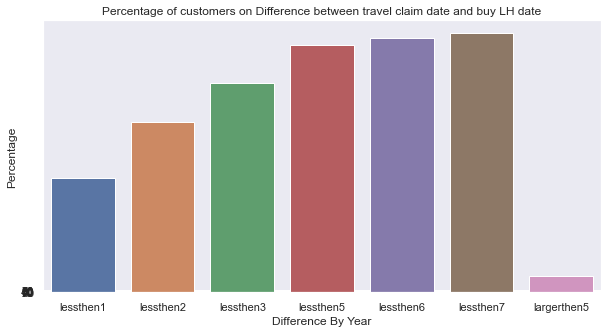

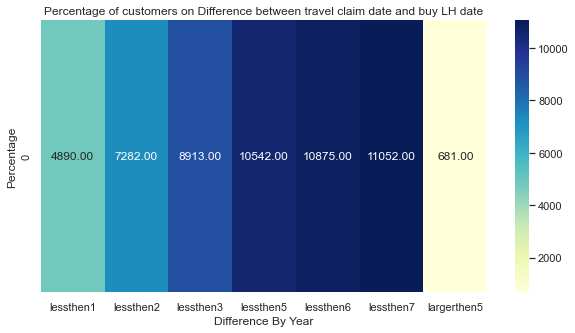

In [98]:
diff_df
# plot a bar chat to show diff_df using plt and seaborn
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# set Y axis to percentage and add title and labels to the chart and show the number of customers on the bottom of each bar 
plt.figure(figsize=(10, 5))
sns.barplot(data=diff_df)
plt.yticks(np.arange(0, 100, 10))
# plt.xticks(rotation=90)
plt.title("Percentage of customers on Difference between travel claim date and buy LH date")
plt.xlabel("Difference By Year")
plt.ylabel("Percentage")
plt.show()

# plot a table to show diff_df using plt and seaborn and add title and labels to the chart and show the number of customers on the bottom of each bar 
plt.figure(figsize=(10, 5))
sns.heatmap(diff_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Percentage of customers on Difference between travel claim date and buy LH date")
plt.xlabel("Difference By Year")
plt.ylabel("Percentage")
plt.show()





In [99]:
# calculate percentage of rows where Diff is less then certain years
lessthen={}
for x in range(1,8):
    no_days=360*x
    lessthen[x]=len(grouped_df[grouped_df['Diff'] < pd.Timedelta(no_days, unit='D')]) 

In [100]:
lessthen

{1: 5372, 2: 8515, 3: 10815, 4: 12360, 5: 13391, 6: 14010, 7: 14313}

In [101]:
# convert lessthen to a dataframe
lessthen_df = pd.DataFrame(lessthen, index=[0])
print(lessthen_df)
# transpose the dataframe
lessthen_df = lessthen_df.T
print (lessthen_df)
# change the column name to "%_DiffY_btw_OCC_and_SUBMIT"
lessthen_df.columns = ["%_of_Diff_Y_btw_DATREP_and_SUBMIT"]
print(lessthen_df)

      1     2      3      4      5      6      7
0  5372  8515  10815  12360  13391  14010  14313
       0
1   5372
2   8515
3  10815
4  12360
5  13391
6  14010
7  14313
   %_of_Diff_Y_btw_DATREP_and_SUBMIT
1                               5372
2                               8515
3                              10815
4                              12360
5                              13391
6                              14010
7                              14313


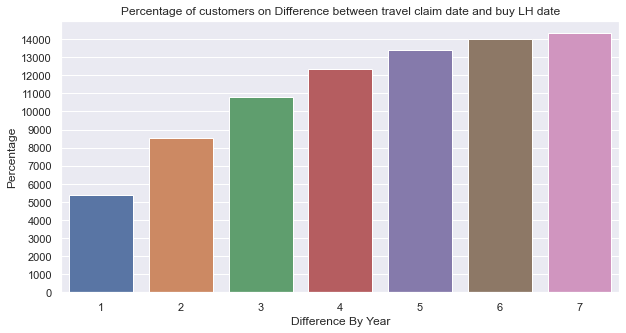

In [102]:
# plot graph for lessthen
plt.figure(figsize=(10, 5))
sns.barplot(x=list(lessthen.keys()), y=list(lessthen.values()))
plt.yticks(np.arange(0, 15000, 1000))
plt.title("Percentage of customers on Difference between travel claim date and buy LH date")
plt.xlabel("Difference By Year")
plt.ylabel("Percentage")
plt.show()

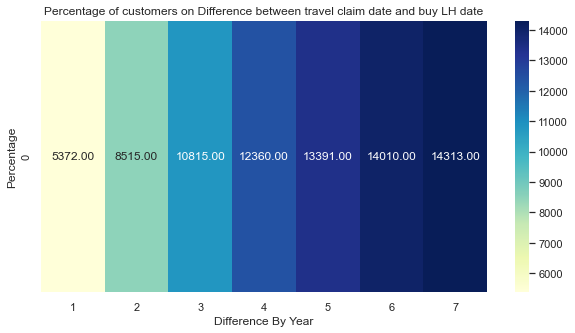

In [103]:
# plot a table for lessthen using plt and seaborn and add title and labels to the chart and show the number of customers on the bottom of each bar 
plt.figure(figsize=(10, 5))
sns.heatmap(pd.DataFrame(lessthen, index=[0]), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Percentage of customers on Difference between travel claim date and buy LH date")
plt.xlabel("Difference By Year")
plt.ylabel("Percentage")
plt.show()

# PLOT Percentage of customers on Difference between travel OCC date and buy LH date 

In [464]:
# merge the two dataframes on the common column ID_NO/modified_SECUITYNO
m_df = pd.merge(useful_LH, useful_prembase_w_client_w_clambase_df, left_on='ID_NO', right_on='modified_SECUITYNO')

# convert columns to datetime type

m_df['SUBMIT_DATE'] = pd.to_datetime(m_df['SUBMIT_DATE'], format="%Y%m%d")
m_df['OCCDATE'] = pd.to_datetime(m_df['OCCDATE'], format="%Y%m%d")

# define a function to calculate the earliest SUBMIT_DATE after each OCCDATE for each modified_SECUITYNO
def calculate_earliest_submit_date(df):
    earliest_submit_date = df[df['SUBMIT_DATE'] > df['OCCDATE']]['SUBMIT_DATE'].min()
    return earliest_submit_date

# group by modified_SECUITYNO and OCCDATE and apply the function
g_df = m_df.groupby(['ID_NO', 'modified_SECUITYNO', 'OCCDATE']).apply(calculate_earliest_submit_date).reset_index()
g_df.columns = ['ID_NO', 'modified_SECUITYNO', 'OCCDATE','earliest_SUBMIT_DATE_after_OCCDATE']

# calculate the diff
g_df['Diff'] = g_df['earliest_SUBMIT_DATE_after_OCCDATE'] - g_df['OCCDATE']

# drop the OCCDATE column if you don't need it anymore
# g_df = g_df.drop(columns=['OCCDATE'])

In [461]:
# see how many rows have DATREP is NaT
len(m_df[~m_df['DATREP'].notnull()])

2631511

In [465]:
m_df.head()

,POLICY_NO,SUBMIT_DATE,POLICY_DATE,ID_NO,OWNER_HKID,contrnb,OCCDATE,channel,product,CLNTNUM,modified_SECUITYNO,CLAIM,CLSTAT,CCDATE,DATOCC,DATREP
0,505-5925183,2022-10-10,2022-10-25,Z134742,,S5159469,2014-12-21,Agents & Broker,SmartTraveller (Single),0688962,Z134742,NaN,NaN,NaN,NaN,NaT
1,505-5925183,2022-10-10,2022-10-25,Z134742,,S5206917,2015-09-09,Agents & Broker,SmartTraveller (Single),0688962,Z134742,NaN,NaN,NaN,NaN,NaT
2,505-5925548,2022-10-10,2022-10-20,K898720,,24389608,2015-07-27,Banca - HSBC,TravelSurance (single trip),2082574,K898720,NaN,NaN,NaN,NaN,NaT
3,505-5925548,2022-10-10,2022-10-20,K898720,,24389608,2015-07-27,Banca - HSBC,TravelSurance (single trip),2082574,K898720,NaN,NaN,NaN,NaN,NaT
4,505-5925548,2022-10-10,2022-10-20,K898720,,24765714,2016-07-24,Banca - HSBC,TravelSurance (single trip),2082574,K898720,NaN,NaN,NaN,NaN,NaT


In [439]:
# group by modified_SECUITYNO and earliest_SUBMIT_DATE_after_OCCDATE, keep only the row with latest OCCDATE
onlylatestOCCDATE=g_df.sort_values('OCCDATE', ascending=False).groupby(['ID_NO', 'modified_SECUITYNO', 'earliest_SUBMIT_DATE_after_OCCDATE']).first().reset_index()


In [468]:
# merge onlylatestOCCDATE with m_df[['modified_SECUITYNO','OCCDATE','DATREP']] on modified_SECUITYNO and OCCDATE
onlylatestOCCDATE_M=pd.merge(onlylatestOCCDATE, m_df[['modified_SECUITYNO','OCCDATE','DATREP']], on=['modified_SECUITYNO','OCCDATE'], how='left')

In [523]:
onlylatestOCCDATE_M.sample(10)

,ID_NO,modified_SECUITYNO,earliest_SUBMIT_DATE_after_OCCDATE,OCCDATE,Diff,DATREP
1124398,Z031577,Z031577,2020-05-22,2016-10-17,1313 days,2016-11-07
583576,E702949,E702949,2020-09-11,2016-08-31,1472 days,2017-08-07
635485,G111789,G111789,2012-05-24,2012-05-09,15 days,2012-05-22
837931,K764466,K764466,2016-06-24,2016-04-02,83 days,2016-05-09
986470,R597394,R597394,2016-04-29,2011-08-12,1722 days,2013-01-18
1121600,Z014990,Z014990,2020-11-02,2018-05-21,896 days,2018-06-15
510903,D373673,D373673,2021-04-29,2018-09-18,954 days,2019-10-03
577459,E611252,E611252,2019-01-25,2015-05-14,1352 days,2018-01-29
1229613,Z910049,Z910049,2020-08-11,2019-07-30,378 days,2019-08-21
668202,G379096,G379096,2019-10-08,2018-11-02,340 days,2019-02-17


In [498]:
# keep this row if DATREP is not NaT and DATREP is betweeen OCCDATE and earliest_SUBMIT_DATE_after_OCCDATE
onlylatestOCCDATE_M=onlylatestOCCDATE_M[(onlylatestOCCDATE_M['DATREP'].notnull()) & (onlylatestOCCDATE_M['DATREP'] > onlylatestOCCDATE_M['OCCDATE']) & (onlylatestOCCDATE_M['DATREP'] < onlylatestOCCDATE_M['earliest_SUBMIT_DATE_after_OCCDATE'])]

In [321]:
(len(g_df[g_df['Diff'] < pd.Timedelta(365*1, unit='D')]) / len(g_df))*100

14.992120030957935

In [524]:
# calculate percentage of rows where Diff is less then certain years
lessThen={}
for x in range(1,8):
    no_days=360*x
    lessThen[x]=len(onlylatestOCCDATE_M[onlylatestOCCDATE_M['Diff'] < pd.Timedelta(no_days, unit='D')]) 

In [525]:
lessThen

{1: 37171, 2: 52743, 3: 63469, 4: 69874, 5: 73928, 6: 76716, 7: 78850}

In [526]:
# convert lessThen to a dataframe
lessThen_df = pd.DataFrame(lessThen, index=[0])
print(lessThen_df)
# transpose the dataframe
lessThen_df = lessThen_df.T
print (lessThen_df)
# change the column name to "%_DiffY_btw_OCC_and_SUBMIT"
lessThen_df.columns = ["No_Diff_Y_btw_OCC_and_SUBMIT"]
print(lessThen_df)


       1      2      3      4      5      6      7
0  37171  52743  63469  69874  73928  76716  78850
       0
1  37171
2  52743
3  63469
4  69874
5  73928
6  76716
7  78850
   No_Diff_Y_btw_OCC_and_SUBMIT
1                         37171
2                         52743
3                         63469
4                         69874
5                         73928
6                         76716
7                         78850


In [527]:
# concat lessthen_df and lessThen_df to a dataframe named diff_df 
diff_df = pd.concat([lessthen_df, lessThen_df], axis=1)
print(diff_df)


   %_of_Diff_Y_btw_DATREP_and_SUBMIT  No_Diff_Y_btw_OCC_and_SUBMIT
1                               5372                         37171
2                               8515                         52743
3                              10815                         63469
4                              12360                         69874
5                              13391                         73928
6                              14010                         76716
7                              14313                         78850


In [529]:
# transpose the dataframe
diff_df = diff_df.T
print (diff_df)

   %_of_Diff_Y_btw_DATREP_and_SUBMIT  No_Diff_Y_btw_OCC_and_SUBMIT
1                               5372                         37171
2                               8515                         52743
3                              10815                         63469
4                              12360                         69874
5                              13391                         73928
6                              14010                         76716
7                              14313                         78850


In [530]:
# change the column name to "%_DiffY_btw_TravelClaim_and_LH" and "%_DiffY_btw_travel_and_LH"
diff_df.columns = ["Num_Diff_Y_btw_TravelClaim_and_LH", "Num_Diff_Y_btw_travel_and_LH"]

In [531]:
# create new col %_DiffY_btw_TravelClaim_and_LH-%_DiffY_btw_travel_and_LH
diff_df['diff'] = diff_df['Num_Diff_Y_btw_TravelClaim_and_LH'] - diff_df['Num_Diff_Y_btw_travel_and_LH']


In [532]:
diff_df

,Num_Diff_Y_btw_TravelClaim_and_LH,Num_Diff_Y_btw_travel_and_LH,diff
1,5372,37171,-31799
2,8515,52743,-44228
3,10815,63469,-52654
4,12360,69874,-57514
5,13391,73928,-60537
6,14010,76716,-62706
7,14313,78850,-64537


In [533]:
# make a new df where calculate the different of rows on the same colume 
new_diff_df = diff_df.diff(axis=0)
print(new_diff_df)

   Num_Diff_Y_btw_TravelClaim_and_LH  Num_Diff_Y_btw_travel_and_LH     diff
1                                NaN                           NaN      NaN
2                             3143.0                       15572.0 -12429.0
3                             2300.0                       10726.0  -8426.0
4                             1545.0                        6405.0  -4860.0
5                             1031.0                        4054.0  -3023.0
6                              619.0                        2788.0  -2169.0
7                              303.0                        2134.0  -1831.0


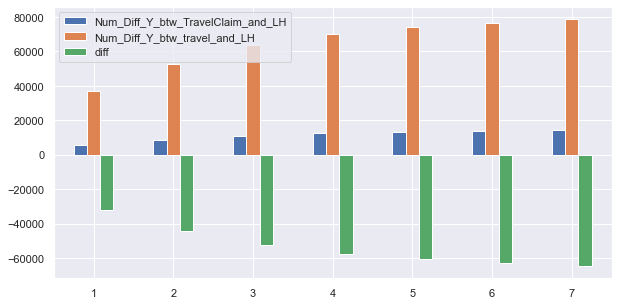

In [534]:
ax = diff_df.plot.bar(rot=0,figsize=(10, 5))

In [ ]:
#Non claim travel and LH

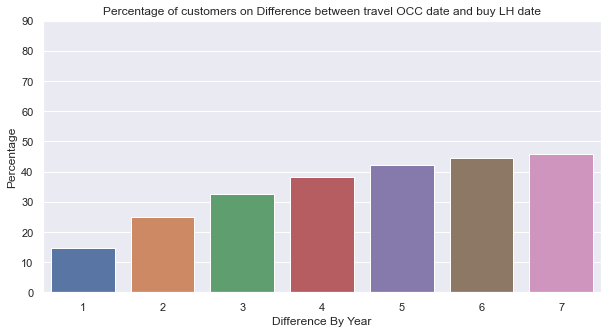

In [337]:
# plot graph for lessThen
plt.figure(figsize=(10, 5))
sns.barplot(x=list(lessThen.keys()), y=list(lessThen.values()))
plt.yticks(np.arange(0, 100, 10))
plt.title("Percentage of customers on Different years between travel OCC date and buy LH date")
plt.xlabel("Difference By Year")
plt.ylabel("Percentage")
plt.show()


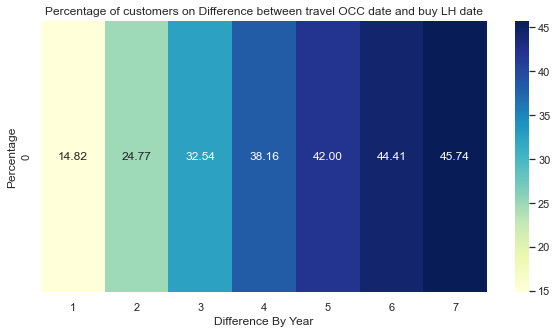

In [338]:
# plot a table for lessThen using plt and seaborn and add title and labels to the chart and show the number of customers on the bottom of each bar
plt.figure(figsize=(10, 5))
sns.heatmap(pd.DataFrame(lessThen, index=[0]), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Percentage of customers on Difference between travel OCC date and buy LH date")
plt.xlabel("Difference By Year")
plt.ylabel("Percentage")
plt.show()


In [210]:
# value count diff column in grouped_df and sort by index ascending order 
grouped_df['Diff']







0       5478 days
1       4152 days
2       3343 days
3        870 days
4             NaT
           ...   
30071         NaT
30072         NaT
30073         NaT
30074         NaT
30075    162 days
Name: Diff, Length: 30076, dtype: timedelta64[ns]

# per year


In [294]:
# show all columns in useful_LH and pcc_groupby
print("useful_LH columns:", useful_LH.columns)
print("pcc_groupby columns:", pcc_groupby.columns)
print("useful_prembase_w_client_w_clambase_df:", pcc_groupby.columns)

useful_LH columns: Index(['POLICY_NO', 'SUBMIT_DATE', 'POLICY_DATE', 'ID_NO', 'OWNER_HKID'], dtype='object')
pcc_groupby columns: Index(['contrnb', 'CLAIM', 'OCCDATE', 'channel', 'product', 'CLNTNUM',
       'modified_SECUITYNO', 'CLSTAT', 'CCDATE', 'DATOCC', 'DATREP'],
      dtype='object')
useful_prembase_w_client_w_clambase_df: Index(['contrnb', 'CLAIM', 'OCCDATE', 'channel', 'product', 'CLNTNUM',
       'modified_SECUITYNO', 'CLSTAT', 'CCDATE', 'DATOCC', 'DATREP'],
      dtype='object')


In [266]:
# value count DATREP column in pcc_groupby and sort by index ascending order
pcc_groupby['DATREP'].value_counts(dropna=False).sort_index()


20010807.0     1
20020411.0     1
20020430.0     1
20020531.0     1
20020605.0     1
              ..
20221021.0     7
20221022.0     1
20221023.0     7
20221024.0     8
20221025.0    12
Name: DATREP, Length: 5191, dtype: int64

In [283]:
# show 10 rows where DATREP == nan
pcc_groupby[pcc_groupby['DATREP'].isna()].head(10)

,contrnb,CLAIM,OCCDATE,channel,product,CLNTNUM,modified_SECUITYNO,CLSTAT,CCDATE,DATOCC,DATREP


In [256]:
pcc_groupby["DATREP"].isna()

,contrnb,CLAIM,OCCDATE,channel,product,CLNTNUM,modified_SECUITYNO,CLSTAT,CCDATE,DATOCC,DATREP
0,00300316,0T035GYA,2011-11-19,Banca - HSBC,MultiTrip TravelSurance (Annual),N5022188,M009061,2,20191119.0,20200212.0,20200316.0
1,00300316,9T01ZMNA,2011-11-19,Banca - HSBC,MultiTrip TravelSurance (Annual),N5022188,M009061,2,20181119.0,20190606.0,20190618.0
2,00300316,Y0383836,2011-11-19,Banca - HSBC,MultiTrip TravelSurance (Annual),N5022188,M009061,2,20151119.0,20160228.0,20160314.0
3,00300316,Y0458943,2011-11-19,Banca - HSBC,MultiTrip TravelSurance (Annual),N5022188,M009061,2,20161119.0,20170423.0,20170508.0
4,00300858,Y0459414,2011-11-21,Banca - HSBC,MultiTrip TravelSurance (Annual),N5030025,R629644,2,20161121.0,20170428.0,20170510.0
...,...,...,...,...,...,...,...,...,...,...,...
152104,Z1640249,2T05H2KA,2022-09-06,Agents & Broker,SmartTraveller Plus (Single),0188248,C363374,1,20220906.0,20220910.0,20220914.0
152105,Z1648184,2A05KTWA,2022-09-02,LP,UNICOVER OVERSEAS STUDENT INS,1659137,G366009,1,20220902.0,20220914.0,20221019.0
152106,Z1648747,2T05I86A,2022-09-14,Agents & Broker,SmartTraveller Plus (Single),0099023,D386128,1,20220914.0,20220915.0,20220923.0
152107,Z1649381,2T05JEJA,2022-09-23,Agents & Broker,SmartTraveller Plus (Single),0591428,3518055,2,20220923.0,20221002.0,20221005.0


In [257]:
useful_LH

,POLICY_NO,SUBMIT_DATE,POLICY_DATE,ID_NO,OWNER_HKID
0,505-5925449,2022-10-10,2022-10-08,E393791,
1,505-5925183,2022-10-10,2022-10-25,Z134742,
2,505-5925548,2022-10-10,2022-10-20,K898720,
3,505-5925340,2022-10-10,2022-10-21,S743037,K880895
4,505-5925464,2022-10-10,2022-10-08,E406942,
...,...,...,...,...,...
5453,505-5294515,2022-06-24,2022-06-24,Y343203,
5454,505-5727746,2022-07-18,2022-07-27,C615117,
5455,505-5729882,2022-07-21,2022-08-15,M348055,
5456,505-5747264,2022-08-18,2022-08-25,Z947224,


# GET NUMBERS

In [ ]:
I have 2 dataframe, useful_LH and useful_prembase_w_client_w_clambase_df
useful_LH is about medical insurance application data

useful_prembase_w_client_w_clambase_df is about travel insurance data

useful_LH has the following columns: Index(['POLICY_NO', 'SUBMIT_DATE', 'POLICY_DATE', 'ID_NO', 'OWNER_HKID'], dtype='object')
useful_prembase_w_client_w_clambase_df has the following columns: Index(['contrnb', 'CLAIM', 'OCCDATE', 'channel', 'product', 'CLNTNUM',
       'modified_SECUITYNO', 'CLSTAT', 'CCDATE', 'DATOCC', 'DATREP'],
      dtype='object')

There's some important columns you need to know:
OCCDATE = date of buying travel insurance
DATREP = date of reporting accident in travel insurance
SUBMIT_DATE = date of submitting medical insurance application
the data of the column ID_NO in useful_LH == the column modified_SECUITYNO in pcc_groupby, they are the same meaning

Give me the codes to Do the following for me:

1)Total number of customer who bought medic after claimed travel = count how many unique modified_SECUITYNO who have DATREP and have SUBMIT_DATE after DATREP within 5 years
2)Number of customer who bought medic but didnt claim= count how many unique modified_SECUITYNO who have OCCDATE and do not have DATREP and have SUBMIT_DATE after OCCDATE within 5 years.
3)Total Number of Customer who bought Medic after buying travel =count how many unique modified_SECUITYNO who have OCCDATE and have SUBMIT_DATE after OCCDATE within 5 years.

In [104]:
useful_prembase_w_client_w_clambase_df[['channel']].value_counts()

channel   
HSBC          3588056
Broker         688065
Live Agent     456367
AXA Direct     159682
others          54268
dtype: int64

In [105]:
merg_df4=pd.merge(useful_LH,useful_prembase_w_client_w_clambase_df , left_on='ID_NO', right_on='modified_SECUITYNO', how='right')

In [106]:
#generate a new DF named "By_Channel" , which has columns name 'HSBC','Broker','AXA Direct','Live Agent','others'
By_Channel = pd.DataFrame(columns=['HSBC','Broker','AXA Direct','Live Agent','others'])



In [107]:
merg_df4.sample(10)

,POLICY_NO,SUBMIT_DATE,POLICY_DATE,ID_NO,OWNER_HKID,contrnb,OCCDATE,channel,product,CLNTNUM,modified_SECUITYNO,CLAIM,CCDATE,DATOCC,DATREP
4055342,NaN,NaT,NaT,NaN,NaN,S5012808,2010-07-10,Broker,SmartTraveller (Annual),0511579,E774367,8T00HKBA,20170710.0,20180516.0,2018-06-06
3734205,NaN,NaT,NaT,NaN,NaN,58338192,1999-03-01,HSBC,MultiTrip TravelSurance (Monthly payment),H3990389,D682842,NaN,NaN,NaN,NaT
4828480,NaN,NaT,NaT,NaN,NaN,S5219713,2015-11-24,Broker,SmartTraveller (Single),0919332,C362858,NaN,NaN,NaN,NaT
6405918,502-6529106,2002-08-27,2002-08-26,C432864,,Z1071893,2018-05-09,Broker,SmartTraveller (Single),1214228,C432864,NaN,NaN,NaN,NaT
3005461,NaN,NaT,NaT,NaN,NaN,25681158,2019-03-30,HSBC,Single Trip 2018,2437046,G041664,NaN,NaN,NaN,NaT
4218194,303-2608162,2008-07-11,2008-07-09,D260697,,S5065012,2012-11-20,Live Agent,SmartTraveller (Single),0146030,D260697,NaN,NaN,NaN,NaT
5313484,504-6158464,2014-05-27,2014-05-27,V035289,,S5337486,2019-01-28,Live Agent,SmartTraveller (Single),1349221,V035289,9T01NSXA,20190128.0,20190131.0,2019-03-27
4723725,303-3220777,2009-03-26,2009-03-28,K279279,,S5193601,2015-07-22,Broker,SmartTraveller (Single),0885182,K279279,NaN,NaN,NaN,NaT
6147313,NaN,NaT,NaT,NaN,NaN,Z0919227,2017-06-10,Broker,SmartTraveller (Single),0963769,Y185850,NaN,NaN,NaN,NaT
5055549,504-9497737,2017-06-27,2017-06-27,D417870,,S5274742,2016-08-12,Live Agent,SmartTraveller (Single),1000635,D417870,NaN,NaN,NaN,NaT


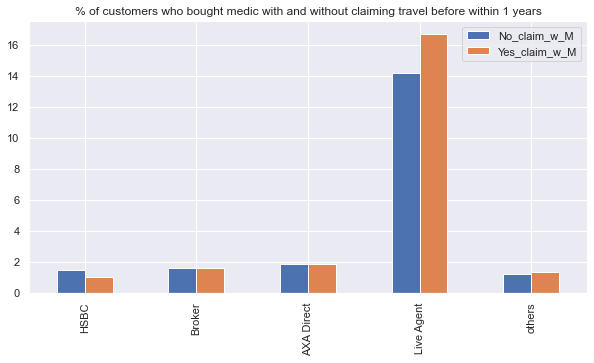

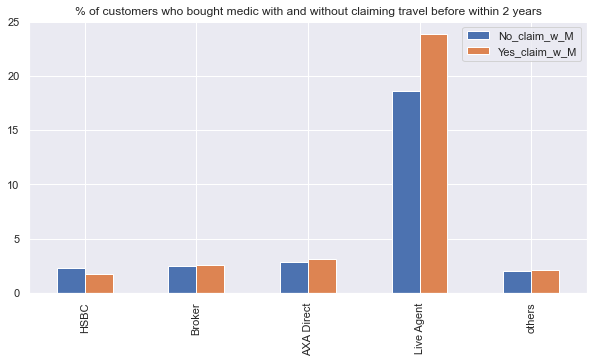

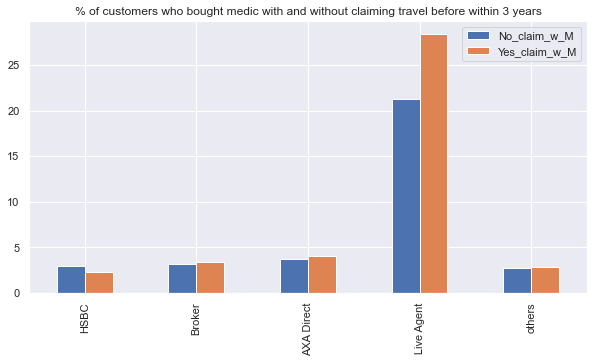

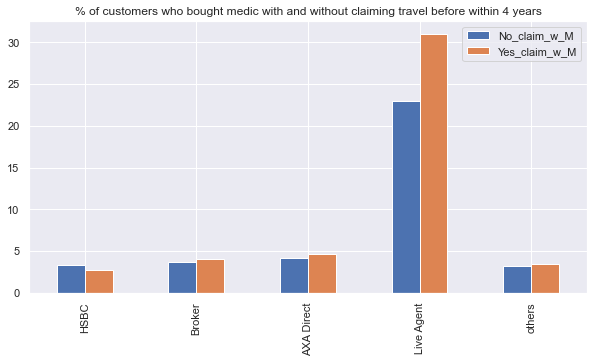

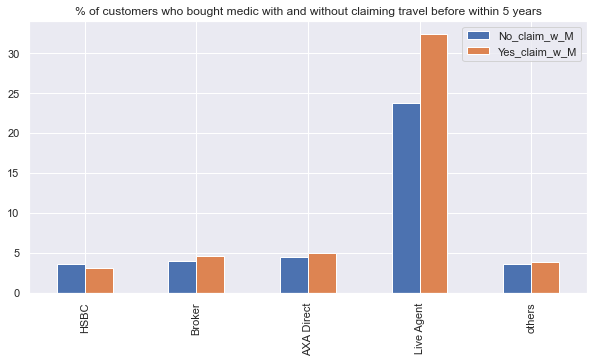

In [108]:
for i in range(1,6):
    for c in ch:
        # filter out only rows with channel == c
        df_c=merg_df4[merg_df4['channel']==c]
        # df_c

        # total number of unique modified_SECUITYNO who have DATREP
        A=len(df_c[df_c['DATREP'].notna()]['modified_SECUITYNO'].unique())
        # print(A)
        
        # for i in range(1,6):
        # i=5
        #total number of unique modified_SECUITYNO who have DATREP and have SUBMIT_DATE after DATREP within i years
        B=len(df_c[(df_c['DATREP'].notna()) & (df_c['SUBMIT_DATE'] > df_c['DATREP']) & (df_c['SUBMIT_DATE'] < df_c['DATREP'] + pd.Timedelta(365*i, unit='D'))]['modified_SECUITYNO'].unique())
        # print(B)
        # total number of unique modified_SECUITYNO who have OCCDATE and do not have DATREP 
        C=len(df_c[(df_c['OCCDATE'].notna()) & (df_c['DATREP'].isna())]['modified_SECUITYNO'].unique())
        # print(C)
        # total number of unique modified_SECUITYNO who have OCCDATE and do not have DATREP and have SUBMIT_DATE after OCCDATE within i years
        D=len(df_c[(df_c['OCCDATE'].notna()) & (df_c['DATREP'].isna()) & (df_c['SUBMIT_DATE'] > df_c['OCCDATE']) & (df_c['SUBMIT_DATE'] < df_c['OCCDATE'] + pd.Timedelta(365*i, unit='D'))]['modified_SECUITYNO'].unique())
        # print(D)

        if(C==0):
            No_claim_w_M=0
        if(A==0):
            Yes_claim_w_M=0
        else:
            No_claim_w_M=(D/C)*100
            Yes_claim_w_M=(B/A)*100

        # add the value to the dataframe By_Channel in the column c and row i 
        By_Channel.loc[0,c]=No_claim_w_M
        By_Channel.loc[1,c]=Yes_claim_w_M

        
    #plot the graph of the dataframe By_Channel.T
    By_Channel.T.plot(kind='bar',figsize=(10,5),title='No_claim_w_M vs Yes_claim_w_M')
    # set legend , blue is No_claim_w_M, orange is Yes_claim_w_M
    plt.legend(['No_claim_w_M','Yes_claim_w_M'])
    # set title to be % of customers who bought medic with and without claiming travel before within 5 years

    plt.title(f'% of customers who buy within {i} years after travel claim vs didnt claim')
    plt.show()


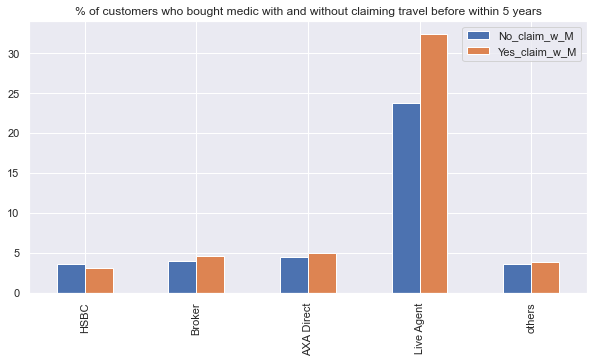

In [310]:
# 4) Total number of customer who have OCCDATE,without DATREP and have SUBMIT_DATE after OCCDATE within 5 years 
# Get only rows who has OCCDATE and without DATREP 
merg_df4=merg_df4[(merg_df4['OCCDATE'].notnull()) & (merg_df4['DATREP'].isnull())]
# Get only rows who has SUBMIT_DATE after OCCDATE within 5 years
a=merg_df4[(merg_df4['SUBMIT_DATE'] > merg_df4['OCCDATE']) & (merg_df4['SUBMIT_DATE'] < merg_df4['OCCDATE']+pd.Timedelta(1825, unit='D'))]['modified_SECUITYNO'].nunique()


# 4.5) Total number of customer who have OCCDATE,without DATREP and without SUBMIT_DATE
# Get only rows who has OCCDATE and without DATREP and with out SUBMIT_DATE
b=merg_df4[(merg_df4['OCCDATE'].notnull()) & (merg_df4['DATREP'].isnull()) & (merg_df4['SUBMIT_DATE'].isnull())]['modified_SECUITYNO'].nunique()
a+b

671955

###

In [312]:
merg_df5=pd.merge(useful_LH,useful_prembase_w_client_w_clambase_df , left_on='ID_NO', right_on='modified_SECUITYNO', how='right')

In [314]:
# 5) Total number of customer who have OCCDATE,have DATREP and have SUBMIT_DATE after DATREP within 5 years 
# Get only rows who has OCCDATE and with DATREP 
merg_df5=merg_df5[(merg_df5['OCCDATE'].notnull()) & (merg_df5['DATREP'].notnull())]
# Get only rows who has SUBMIT_DATE after DATREP within 5 years
c=merg_df5[(merg_df5['SUBMIT_DATE'] > merg_df5['DATREP']) & (merg_df5['SUBMIT_DATE'] < merg_df5['DATREP']+pd.Timedelta(1825, unit='D'))]['modified_SECUITYNO'].nunique()


# 5.5) Total number of customer who have OCCDATE,have DATREP and without SUBMIT_DATE
# Get only rows who has OCCDATE and have DATREP and with out SUBMIT_DATE
d=merg_df5[(merg_df5['OCCDATE'].notnull()) & (merg_df5['DATREP'].notnull()) & (merg_df5['SUBMIT_DATE'].isnull())]['modified_SECUITYNO'].nunique()
c+d

94592

In [315]:
(48631/671955)*100

7.2372405890275395

In [316]:
(9314/94592)*100

9.846498646820027

In [302]:
merg_df1 = pd.merge(useful_LH, useful_prembase_w_client_w_clambase_df, left_on='ID_NO', right_on='modified_SECUITYNO')

In [303]:
# drop if DATREP is nan
merg_df1 = merg_df1[merg_df1['DATREP'].notna()]

# drop if SUBMIT_DATE is nan
merg_df1 = merg_df1[merg_df1['SUBMIT_DATE'].notna()]

# drop if SUBMIT_DATE is less then DATREP and larger then DATREP + 5 years
merg_df1 = merg_df1[(merg_df1['SUBMIT_DATE'] > merg_df1['DATREP']) & (merg_df1['SUBMIT_DATE'] < merg_df1['DATREP'] + pd.DateOffset(years=5))]
# show the number of unique modified_SECUITYNO in merg_df1
merg_df1['modified_SECUITYNO'].nunique()


9314

In [304]:
merg_df2 = pd.merge(useful_LH, useful_prembase_w_client_w_clambase_df, left_on='ID_NO', right_on='modified_SECUITYNO')

In [305]:
# get only rows who have OCCDATE and do not have DATREP
merg_df2 = merg_df2[(merg_df2['OCCDATE'].notna()) & (merg_df2['DATREP'].isna())]
# get only rows who have SUBMIT_DATE and SUBMIT_DATE is larger then OCCDATE and smaller then OCCDATE + 5 years
merg_df2 = merg_df2[(merg_df2['SUBMIT_DATE'].notna()) & (merg_df2['SUBMIT_DATE'] > merg_df2['OCCDATE']) & (merg_df2['SUBMIT_DATE'] < merg_df2['OCCDATE'] + pd.DateOffset(years=5))]
# show the number of unique modified_SECUITYNO in merg_df2
merg_df2['modified_SECUITYNO'].nunique()

48631

In [306]:
merg_df3 = pd.merge(useful_LH, useful_prembase_w_client_w_clambase_df, left_on='ID_NO', right_on='modified_SECUITYNO')

In [308]:
#count how many unique modified_SECUITYNO who have OCCDATE and have SUBMIT_DATE after OCCDATE within 5 years.
merg_df3 = merg_df3[(merg_df3['OCCDATE'].notna()) & (merg_df3['SUBMIT_DATE'].notna()) & (merg_df3['SUBMIT_DATE'] > merg_df3['OCCDATE']) & (merg_df3['SUBMIT_DATE'] < merg_df3['OCCDATE'] + pd.DateOffset(years=5))]
# show the number of unique modified_SECUITYNO in merg_df3
merg_df3['modified_SECUITYNO'].nunique()

50677

In [298]:
# convert useful_prembase_w_client_w_clambase_df['DATREP'] to datetime 
useful_prembase_w_client_w_clambase_df['DATREP'] = pd.to_datetime(useful_prembase_w_client_w_clambase_df['DATREP'], format='%Y%m%d')

In [297]:
useful_LH['SUBMIT_DATE']

0      2022-10-10
1      2022-10-10
2      2022-10-10
3      2022-10-10
4      2022-10-10
          ...    
5453   2022-06-24
5454   2022-07-18
5455   2022-07-21
5456   2022-08-18
5457   2022-08-18
Name: SUBMIT_DATE, Length: 1921779, dtype: datetime64[ns]

# plot graph of ex: if buy LH at certain year, how many ppl have claimed within certain year

In [ ]:
I have 2 dataframe, useful_LH and pcc_groupby
useful_LH is about medical insurance data
pcc_groupby is about travel insurance data
useful_LH columns: Index(['POLICY_NO', 'SUBMIT_DATE', 'POLICY_DATE', 'ID_NO', 'OWNER_HKID'], dtype='object')
pcc_groupby columns: Index(['contrnb', 'CLAIM', 'OCCDATE', 'channel', 'product', 'CLNTNUM',
       'modified_SECUITYNO', 'CLSTAT', 'CCDATE', 'DATOCC', 'DATREP'],
      dtype='object')
There's some important columns you need to know:
OCCDATE: date of buying travel insurance
DATREP = date of claim in travel insurance
SUBMIT_DATE = date of buying medical insurance 
the data of the column ID_NO in useful_LH == the column modified_SECUITYNO in pcc_groupby, they are the same, means the same person.


I want to know the comparison between (1) and (2) in the following questions:

(1)number of  people who have bought travel insurance(have OCCDATE) and have claimed insurance(have DATREP) within 1-5 years before buying medical insurance(SUBMIT_DATE).
(2)number of  people who have bought travel insurance(have OCCDATE) and have not claimed insurance(have DATREP) within 1-5 years before buying medical insurance(SUBMIT_DATE).

In [113]:
#generate a new DF named "By_Channel" , which has columns name 'HSBC','Broker','AXA Direct','Live Agent','others'
By_Chan = pd.DataFrame(columns=['HSBC','Broker','AXA Direct','Live Agent','others'])


In [117]:
ch

['HSBC', 'Broker', 'AXA Direct', 'Live Agent', 'others']

In [112]:
merged_df5 = pd.merge(useful_LH, pcc_groupby, left_on='ID_NO', right_on='modified_SECUITYNO', how='inner')

Number of individuals who have claimed insurance within 1 years before buying medical insurance:  4080
Number of individuals who have not claimed insurance within 1 years before buying medical insurance:  32450
Number of individuals who have claimed insurance within 1 years before buying medical insurance:  2670
Number of individuals who have not claimed insurance within 1 years before buying medical insurance:  16592
Number of individuals who have claimed insurance within 1 years before buying medical insurance:  1042
Number of individuals who have not claimed insurance within 1 years before buying medical insurance:  7353
Number of individuals who have claimed insurance within 1 years before buying medical insurance:  11017
Number of individuals who have not claimed insurance within 1 years before buying medical insurance:  52800
Number of individuals who have claimed insurance within 1 years before buying medical insurance:  268
Number of individuals who have not claimed insurance w

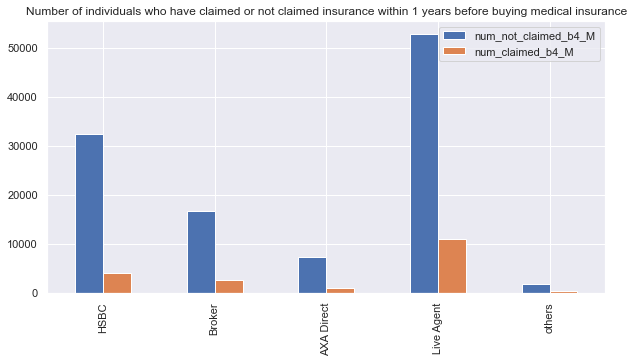

Number of individuals who have claimed insurance within 2 years before buying medical insurance:  4253
Number of individuals who have not claimed insurance within 2 years before buying medical insurance:  33919
Number of individuals who have claimed insurance within 2 years before buying medical insurance:  2779
Number of individuals who have not claimed insurance within 2 years before buying medical insurance:  17266
Number of individuals who have claimed insurance within 2 years before buying medical insurance:  1102
Number of individuals who have not claimed insurance within 2 years before buying medical insurance:  7684
Number of individuals who have claimed insurance within 2 years before buying medical insurance:  11230
Number of individuals who have not claimed insurance within 2 years before buying medical insurance:  53915
Number of individuals who have claimed insurance within 2 years before buying medical insurance:  282
Number of individuals who have not claimed insurance w

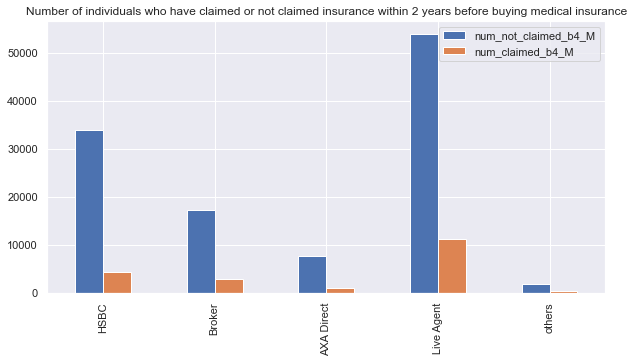

Number of individuals who have claimed insurance within 3 years before buying medical insurance:  4412
Number of individuals who have not claimed insurance within 3 years before buying medical insurance:  35137
Number of individuals who have claimed insurance within 3 years before buying medical insurance:  2874
Number of individuals who have not claimed insurance within 3 years before buying medical insurance:  17832
Number of individuals who have claimed insurance within 3 years before buying medical insurance:  1149
Number of individuals who have not claimed insurance within 3 years before buying medical insurance:  7962
Number of individuals who have claimed insurance within 3 years before buying medical insurance:  11391
Number of individuals who have not claimed insurance within 3 years before buying medical insurance:  54662
Number of individuals who have claimed insurance within 3 years before buying medical insurance:  294
Number of individuals who have not claimed insurance w

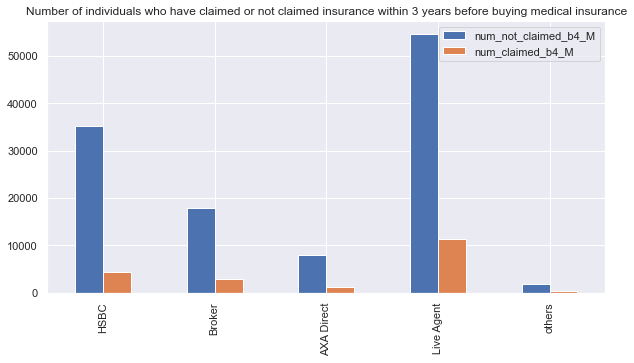

Number of individuals who have claimed insurance within 4 years before buying medical insurance:  4538
Number of individuals who have not claimed insurance within 4 years before buying medical insurance:  35996
Number of individuals who have claimed insurance within 4 years before buying medical insurance:  2951
Number of individuals who have not claimed insurance within 4 years before buying medical insurance:  18243
Number of individuals who have claimed insurance within 4 years before buying medical insurance:  1187
Number of individuals who have not claimed insurance within 4 years before buying medical insurance:  8178
Number of individuals who have claimed insurance within 4 years before buying medical insurance:  11494
Number of individuals who have not claimed insurance within 4 years before buying medical insurance:  55133
Number of individuals who have claimed insurance within 4 years before buying medical insurance:  302
Number of individuals who have not claimed insurance w

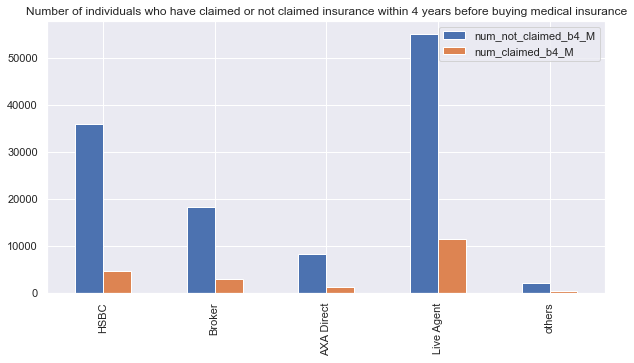

Number of individuals who have claimed insurance within 5 years before buying medical insurance:  4656
Number of individuals who have not claimed insurance within 5 years before buying medical insurance:  36618
Number of individuals who have claimed insurance within 5 years before buying medical insurance:  3028
Number of individuals who have not claimed insurance within 5 years before buying medical insurance:  18562
Number of individuals who have claimed insurance within 5 years before buying medical insurance:  1215
Number of individuals who have not claimed insurance within 5 years before buying medical insurance:  8283
Number of individuals who have claimed insurance within 5 years before buying medical insurance:  11555
Number of individuals who have not claimed insurance within 5 years before buying medical insurance:  55374
Number of individuals who have claimed insurance within 5 years before buying medical insurance:  308
Number of individuals who have not claimed insurance w

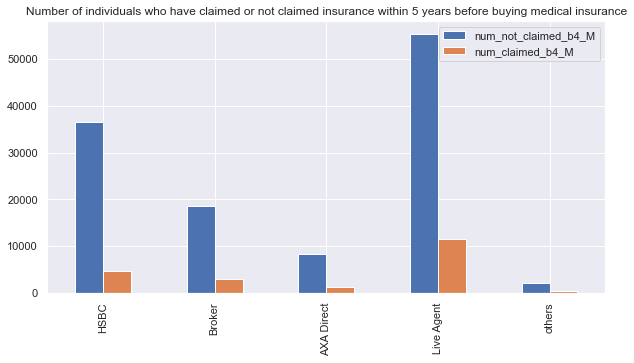

In [119]:
for i in range(1,6):
    for c in ch:
        # Merge the two dataframes on 'modified_SECUITYNO'
        df_c=merged_df5[merged_df5['channel']==c]

        # Create a new column 'years_before' to calculate the number of years between 'SUBMIT_DATE' and 'OCCDATE'
        df_c['years_before'] = (df_c['SUBMIT_DATE'] - df_c['OCCDATE']).dt.days / 365.25

        # Subset the merged dataframe to only include individuals who have bought travel insurance (have 'OCCDATE')
        subset1 = df_c[df_c['OCCDATE'].notnull()]

        # Subset the merged dataframe to only include individuals who have claimed insurance (have 'DATREP') within 1-5 years before buying medical insurance ('SUBMIT_DATE')
        subset2 = subset1[(subset1['DATREP'].notnull()) &  (subset1['years_before'] <= i)]

        # Count the number of individuals who meet the above conditions
        num_claimed = subset2['ID_NO'].nunique()

        # Subset the merged dataframe to only include individuals who have not claimed insurance (have no 'DATREP') within 1-5 years before buying medical insurance ('SUBMIT_DATE')
        subset3 = subset1[(subset1['DATREP'].isnull()) &(subset1['years_before'] <= i)]

        # Count the number of individuals who meet the above conditions
        num_not_claimed = subset3['ID_NO'].nunique()

        # Print the results
        print(f"Number of individuals who have claimed insurance within {i} years before buying medical insurance: ", num_claimed)
        print(f"Number of individuals who have not claimed insurance within {i} years before buying medical insurance: ", num_not_claimed)


        By_Chan.loc[0,c]=num_not_claimed
        By_Chan.loc[1,c]=num_claimed
    #plot the graph of the dataframe By_Chan.T
    print(By_Chan)
    By_Chan.T.plot(kind='bar',figsize=(10,5),title='num_not_claimed_b4_M vs num_claimed_b4_M')
    # set legend , blue is No_claim_w_M, orange is Yes_claim_w_M
    plt.legend(['num_not_claimed_b4_M','num_claimed_b4_M'])
    # set title to be % of customers who bought medic with and without claiming travel before within 5 years
    plt.title(f'Number of individuals who have claimed or not claimed insurance within {i} years before buying medical insurance')
    plt.show()